In [ ]:
#Importing Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
#Defining path

In [2]:
DATASET_PATH = r"C:\Data Science\NEU-DET"

TRAIN_IMAGES = os.path.join(
    DATASET_PATH,
    "train",
    "images"
)

VAL_IMAGES = os.path.join(
    DATASET_PATH,
    "validation",
    "images"
)

In [ ]:
#Define classes

In [3]:
classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

In [4]:
#Loaded the trainig dataset

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_IMAGES,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 1440 files belonging to 6 classes.


In [6]:
#Loaded validation dataset

In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_IMAGES,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 360 files belonging to 6 classes.


In [8]:
#Create Augumentation

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

In [10]:
#load Resnet 50
base_model = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [11]:
#Freeze RSNet 50
base_model.trainable = False

In [12]:
#Build Classification Model
inputs = keras.Input(
    shape=(224, 224, 3)
)

x = data_augmentation(inputs)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs,
    outputs
)

In [13]:
#Checking the model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,850,758 (90.98 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
#Compile
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
#Train the frozen ResNet 50
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


45/45 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.4201 - loss: 1.5028 - val_accuracy: 0.8861 - val_loss: 0.8780
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - accuracy: 0.8076 - loss: 0.6805 - val_accuracy: 0.9056 - val_loss: 0.5197
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 179s 4s/step - accuracy: 0.8986 - loss: 0.4339 - val_accuracy: 0.9111 - val_loss: 0.3781
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.9319 - loss: 0.3006 - val_accuracy: 0.9222 - val_loss: 0.3030
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 292s 7s/step - accuracy: 0.9576 - loss: 0.2313 - val_accuracy: 0.9389 - val_loss: 0.2603
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.9660 - loss: 0.1767 - val_accuracy: 0.9389 - val_loss: 0.2249
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 490s 11s/step - accuracy: 0.9681 - loss: 0.1534 - val_accuracy: 0.9417 - val_loss: 0.1979
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.9708 - loss: 0.1276 - val_accuracy: 0.9444 - val_loss: 0.

In [16]:
#Evaluate
val_loss, val_accuracy = model.evaluate(
    val_ds
)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9389 - loss: 0.1549
Validation Loss: 0.1549243927001953
Validation Accuracy: 0.9388889074325562


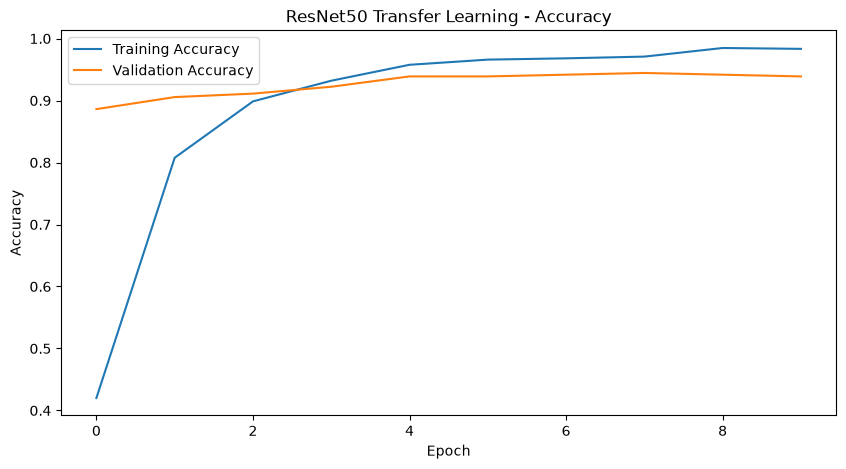

In [17]:
#Plot Accuracy
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Transfer Learning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

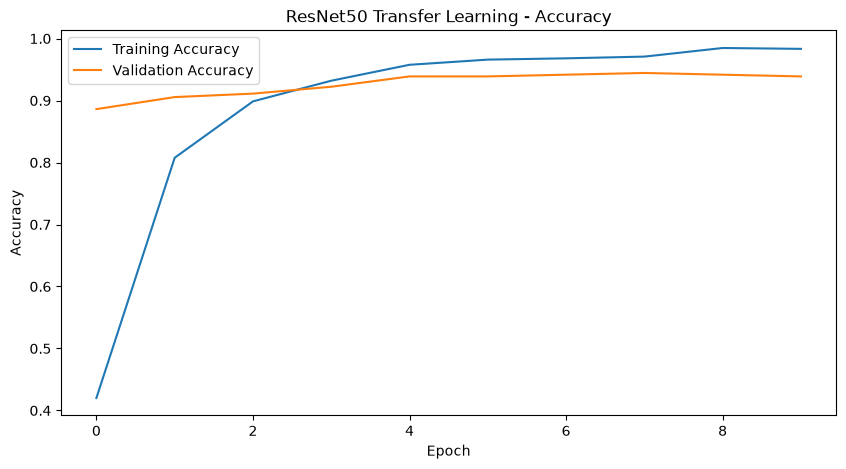

In [18]:
#Plot Loss
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ResNet50 Transfer Learning - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [20]:
#Check ResNet 50
print("Total ResNet50 layers:", len(base_model.layers))

Total ResNet50 layers: 175


In [21]:
for i, layer in enumerate(base_model.layers[-25:]):
    print(i - 25, layer.name, layer.trainable)

-25 conv5_block1_3_conv False
-24 conv5_block1_0_bn False
-23 conv5_block1_3_bn False
-22 conv5_block1_add False
-21 conv5_block1_out False
-20 conv5_block2_1_conv False
-19 conv5_block2_1_bn False
-18 conv5_block2_1_relu False
-17 conv5_block2_2_conv False
-16 conv5_block2_2_bn False
-15 conv5_block2_2_relu False
-14 conv5_block2_3_conv False
-13 conv5_block2_3_bn False
-12 conv5_block2_add False
-11 conv5_block2_out False
-10 conv5_block3_1_conv False
-9 conv5_block3_1_bn False
-8 conv5_block3_1_relu False
-7 conv5_block3_2_conv False
-6 conv5_block3_2_bn False
-5 conv5_block3_2_relu False
-4 conv5_block3_3_conv False
-3 conv5_block3_3_bn False
-2 conv5_block3_add False
-1 conv5_block3_out False


In [22]:
# Unfreeze only the last ~20 layers
# First freeze everything
base_model.trainable = True

# Freeze all layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep the last 20 layers trainable
for layer in base_model.layers[-20:]:
    layer.trainable = True

In [23]:
#Verifiying it
trainable_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print("Number of trainable layers:", len(trainable_layers))
print("\nTrainable layers:")

for layer in trainable_layers:
    print(layer)

Number of trainable layers: 20

Trainable layers:
conv5_block2_1_conv
conv5_block2_1_bn
conv5_block2_1_relu
conv5_block2_2_conv
conv5_block2_2_bn
conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


In [24]:
# Important: Batch Normalization
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

In [25]:
trainable_count = sum(
    layer.trainable
    for layer in base_model.layers
)

print("Trainable ResNet50 layers:", trainable_count)

Trainable ResNet50 layers: 14


In [26]:
#Recompile the model
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
#Fine tune
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.9833 - loss: 0.0601 - val_accuracy: 0.9639 - val_loss: 0.0984
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 430s 10s/step - accuracy: 0.9889 - loss: 0.0385 - val_accuracy: 0.9722 - val_loss: 0.0729
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.9931 - loss: 0.0264 - val_accuracy: 0.9722 - val_loss: 0.0612
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 288s 6s/step - accuracy: 0.9924 - loss: 0.0209 - val_accuracy: 0.9833 - val_loss: 0.0489
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.9965 - loss: 0.0167 - val_accuracy: 0.9694 - val_loss: 0.0888


In [28]:
#Evaluate
fine_val_loss, fine_val_accuracy = model.evaluate(
    val_ds
)

print("Fine-tuned Validation Loss:", fine_val_loss)
print("Fine-tuned Validation Accuracy:", fine_val_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9694 - loss: 0.0888
Fine-tuned Validation Loss: 0.0887683779001236
Fine-tuned Validation Accuracy: 0.9694444537162781


In [ ]:
#Final model Evalution

In [32]:
#Save the fine tuned model seperately
model.save("resnet50_finetuned.keras")

In [37]:
# #Reload the frozen ResNet50
# final_model = keras.models.load_model(
#     "resnet50_frozen.keras"
# )

In [38]:
# final_loss, final_accuracy = final_model.evaluate(
#     val_ds
# )

# print("Final Model Loss:", final_loss)
# print("Final Model Accuracy:", final_accuracy)

In [39]:
# import os

# print("Current folder:")
# print(os.getcwd())

# print("\nFiles:")
# print(os.listdir())

In [35]:
from tensorflow import keras

final_model = keras.models.load_model(
    "resnet50_finetuned.keras"
)

print("Fine-tuned ResNet50 loaded successfully!")

Fine-tuned ResNet50 loaded successfully!


In [36]:
fine_loss, fine_accuracy = final_model.evaluate(
    val_ds
)

print("Validation Loss:", fine_loss)
print("Validation Accuracy:", fine_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9694 - loss: 0.0888
Validation Loss: 0.0887683779001236
Validation Accuracy: 0.9694444537162781


In [40]:
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:

    probabilities = final_model.predict(
        images,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)
print("Probabilities:", y_prob.shape)

True labels: (360,)
Predicted labels: (360,)
Probabilities: (360, 6)


In [41]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       1.00      0.82      0.90        60
        patches       1.00      1.00      1.00        60
 pitted_surface       0.95      1.00      0.98        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.88      1.00      0.94        60

       accuracy                           0.97       360
      macro avg       0.97      0.97      0.97       360
   weighted avg       0.97      0.97      0.97       360



In [42]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[60  0  0  0  0  0]
 [ 0 49  0  3  0  8]
 [ 0  0 60  0  0  0]
 [ 0  0  0 60  0  0]
 [ 0  0  0  0 60  0]
 [ 0  0  0  0  0 60]]


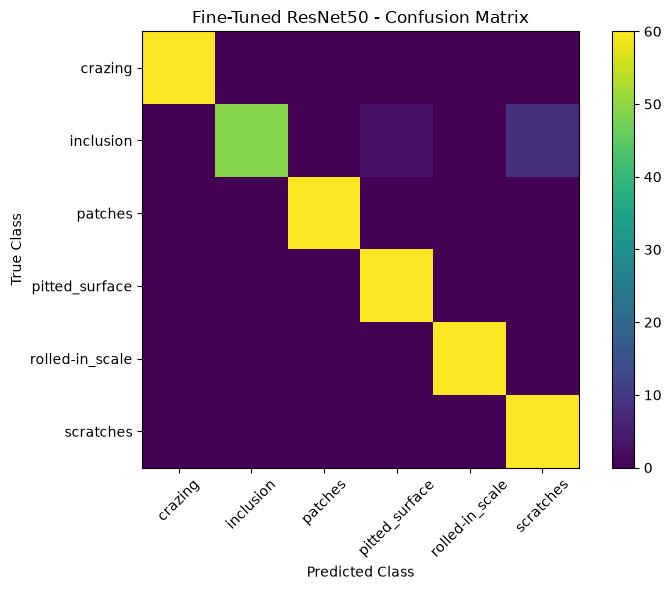

In [43]:
#Visualize
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Fine-Tuned ResNet50 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [44]:
#Next: ROC-AUC
y_prob

array([[9.9981183e-01, 4.0702336e-08, 4.7809404e-05, 1.3954169e-04,
        4.3629120e-07, 3.3444715e-07],
       [9.9998522e-01, 6.9761357e-09, 4.1346411e-06, 1.0328509e-05,
        1.4643400e-07, 1.2968719e-07],
       [9.9988890e-01, 8.4274781e-08, 3.6509085e-05, 7.0410024e-05,
        3.5976657e-06, 5.8366447e-07],
       ...,
       [2.1078892e-12, 1.6398445e-09, 2.4092605e-08, 1.6084460e-09,
        1.8065656e-10, 1.0000000e+00],
       [1.6759638e-10, 5.3255974e-08, 2.1368598e-07, 1.4161580e-08,
        1.4832635e-08, 9.9999976e-01],
       [7.9880655e-13, 1.9497262e-10, 2.1617616e-08, 1.9230799e-09,
        7.3761032e-11, 1.0000000e+00]], shape=(360, 6), dtype=float32)

In [45]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_true_binary = label_binarize(
    y_true,
    classes=range(len(classes))
)

roc_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("Macro ROC-AUC:", roc_auc)

Macro ROC-AUC: 0.999962962962963


In [46]:
#Precision reacll_AUC
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_true_binary,
    y_prob,
    average="macro"
)

print("Macro PR-AUC:", pr_auc)

Macro PR-AUC: 0.9998163327261688


In [47]:
#Check for duplicate images
import os
import hashlib

def get_image_hashes(folder):
    hashes = {}

    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                
                path = os.path.join(root, file)

                with open(path, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                hashes[file_hash] = path

    return hashes


train_hashes = get_image_hashes(TRAIN_IMAGES)
val_hashes = get_image_hashes(VAL_IMAGES)

duplicates = set(train_hashes.keys()).intersection(
    set(val_hashes.keys())
)

print("Training images:", len(train_hashes))
print("Validation images:", len(val_hashes))
print("Exact duplicate images:", len(duplicates))

Training images: 1439
Validation images: 360
Exact duplicate images: 0


In [48]:
print("base_model trainable:", base_model.trainable)

trainable_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print("Trainable ResNet50 layers:", trainable_layers)

base_model trainable: True
Trainable ResNet50 layers: 14


In [49]:
#Prepare deployment model
import tensorflow as tf
from tensorflow import keras

deployment_model = keras.models.load_model(
    "resnet50_finetuned.keras"
)

print("Model loaded successfully.")

Model loaded successfully.


In [50]:
print(deployment_model.input_shape)
print(deployment_model.output_shape)

(None, 224, 224, 3)
(None, 6)


In [51]:
#Create the prediction function
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

def predict_defect(image_path):

    # Load image
    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert to array
    image_array = img_to_array(image)

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    # Predict
    probabilities = deployment_model.predict(
        image_array,
        verbose=0
    )[0]

    # Get predicted class
    predicted_index = np.argmax(probabilities)

    predicted_class = classes[predicted_index]

    confidence = probabilities[predicted_index] * 100

    return predicted_class, confidence

In [53]:
#Test with an actual defeact steel image
image_path = r"C:\Data Science\NEU-DET\validation\images\crazing\some_image.jpg"

predicted_class, confidence = predict_defect(
    image_path
)

print("Predicted defect:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Data Science\\NEU-DET\\validation\\images\\crazing\\some_image.jpg'

In [54]:
import os

validation_path = r"C:\Data Science\NEU-DET\validation\images"

for root, dirs, files in os.walk(validation_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))
            break
    break

In [55]:
import os

validation_path = r"C:\Data Science\NEU-DET\validation\images"

image_path = None

for root, dirs, files in os.walk(validation_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(root, file)
            break

    if image_path:
        break

print("Image found:")
print(image_path)

Image found:
C:\Data Science\NEU-DET\validation\images\crazing\crazing_241.jpg


In [56]:
predicted_class, confidence = predict_defect(
    image_path
)

print("Predicted defect:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

Predicted defect: crazing
Confidence: 96.60%


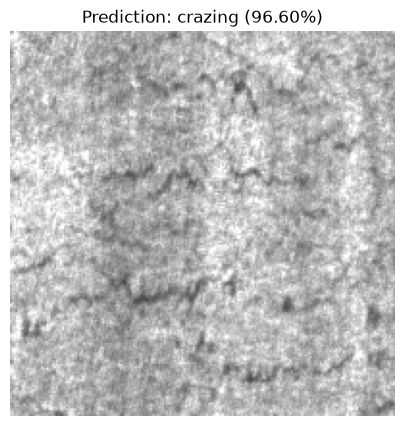

In [57]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(
    f"Prediction: {predicted_class} ({confidence:.2f}%)"
)
plt.axis("off")
plt.show()

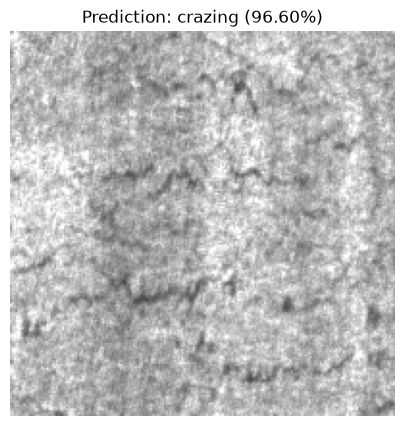

In [59]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(
    f"Prediction: {predicted_class} ({confidence:.2f}%)"
)
plt.axis("off")
plt.show()

In [60]:
predicted_class, confidence = predict_defect(image_path)

print("Predicted defect:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

Predicted defect: crazing
Confidence: 96.60%


In [61]:
#Test all 6 classes
import os

validation_path = r"C:\Data Science\NEU-DET\validation\images"

for class_name in classes:

    class_path = os.path.join(
        validation_path,
        class_name
    )

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if len(image_files) > 0:

        test_image = os.path.join(
            class_path,
            image_files[0]
        )

        predicted, confidence = predict_defect(
            test_image
        )

        print(
            f"Actual: {class_name:18s} | "
            f"Predicted: {predicted:18s} | "
            f"Confidence: {confidence:.2f}%"
        )

Actual: crazing            | Predicted: crazing            | Confidence: 96.60%
Actual: inclusion          | Predicted: inclusion          | Confidence: 77.26%
Actual: patches            | Predicted: patches            | Confidence: 99.51%
Actual: pitted_surface     | Predicted: pitted_surface     | Confidence: 99.99%
Actual: rolled-in_scale    | Predicted: rolled-in_scale    | Confidence: 99.80%
Actual: scratches          | Predicted: scratches          | Confidence: 100.00%
